# Q2: Vision Language Models (VLMs)

# S1: VLM Anatomy

**Objective:** In this section, you will learn the anatomy of Vision-Language Models (VLMs), identify their core components, and practically explore how images are translated into tokens that a Large Language Model (LLM) can process.

## 1. Model Anatomy

A typical Vision-Language Model usually consists of three main components:

- **Vision Encoder:** A neural network (often a Vision Transformer or ViT) that processes the raw image to extract visual features.
- **Vision-Language Projector:** Linear layers or MLPs that map the extracted visual features into the same dimensional space as the text tokens.
- **Large Language Model:** The core LLM that processes the combined sequence of text and visual tokens to generate an output.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Task 1.1: Load and Inspect the Model



In [3]:
!pip install qwen_vl_utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 22.7 MB/s eta 0:00:00


### Import Libraries

In [4]:
import time
import random
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoProcessor,
    AutoModelForMultimodalLM,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model
from qwen_vl_utils import process_vision_info

Complete and run the code cell below to use the transformers library to load the Qwen/Qwen3.5-0.8B model and its processor, and print the underlying model architecture.


In [5]:
model_id = "Qwen/Qwen3.5-0.8B"

# Load processor
processor = AutoProcessor.from_pretrained(model_id)

# Load model (using bfloat16 for efficiency; float16 also works)
model = AutoModelForMultimodalLM.from_pretrained(
    model_id,
    dtype="bfloat16",
    device_map="auto"
)

print(model)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Qwen3_5ForConditionalGeneration(
  (model): Qwen3_5Model(
    (visual): Qwen3_5VisionModel(
      (patch_embed): Qwen3_5VisionPatchEmbed(
        (proj): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 768)
      (rotary_pos_emb): Qwen3_5VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-11): 12 x Qwen3_5VisionBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3_5VisionAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (mlp): Qwen3_5VisionMLP(
            (linear_fc1): Linear(in_features=768, out_features=3072, bias=True)
            (linear_fc2): Linear(in_features=3072, out_features=768, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
      (mer

**Question 1.1:** Inspect the printed model architecture layout above. Identify and write down the exact module or class names corresponding to the Vision Encoder, the Projector, and the Large Language Model components.

**Student's Answer:**

<div dir="rtl">

براساس ساختار چاپی مدل، نام دقیق کلاس‌ها و توضیح عملکرد هر بخش به شرح زیر است:

**بخش Vision Encoder (کلاس `Qwen3_5VisionModel`):**
   این ماژول وظیفه پردازش تصاویر ورودی و استخراج ویژگی‌های بصری را بر عهده دارد. تصویر ابتدا به تکه‌های کوچک‌تر تقسیم شده و سپس لایه‌های بینایی ویژگی‌های ساختاری و معنایی تصویر را استخراج می‌کنند.

**بخش Projector (کلاس `Qwen3_5VisionPatchMerger`):**
   این بخش به عنوان یک پل ارتباطی بین بخش بینایی و بخش زبانی عمل می‌کند. وظیفه آن تراز کردن و انتقال ویژگی‌های تصویر به همان فضای امبدینگ متنی است تا مدل زبانی بتواند داده‌های تصویری را درک کند.

**بخش Large Language Model (کلاس `Qwen3_5TextModel`):**
   هسته اصلی و مغز متفکر مدل است که وظیفه پردازش متن را بر عهده دارد. این لایه نشانه‌های متنی (Tokens) و ویژگی‌های تراز شده تصویر را دریافت کرده، روی آن‌ها استدلال می‌کند و پاسخ متنی نهایی را تولید می‌نماید.

</div>


## 2. Baseline Inference

Let's test the model on real data to see how it performs. We will break this down into three steps: loading data, formatting the multimodal prompts, and generating the responses.

### Important Note: Non-Thinking Mode

For all evaluations and fine-tuning tasks in this notebook, you must set the model to **Non-thinking mode** to test its pure Instruct behavior.

For technical details, check the [Hugging Face Qwen3.5 Documentation](https://huggingface.co/Qwen/Qwen3.5-0.8B).

### Task 1.2a: Load and Explore the Dataset

Complete and run the code below to load the ScienceQA dataset, filter it for samples containing image, and select 3 samples of your choice.

In [6]:
dataset = load_dataset("derek-thomas/ScienceQA")

# Filter the 'train' split to keep ONLY samples with an 'image'
image_data = dataset["train"].filter(lambda x: x["image"] is not None)

# Select 3 samples of your choice from image_data
random.seed(36)
selected_samples = image_data.select(random.sample(range(len(image_data)), 3))
print(selected_samples)

README.md:   0%|          | 0.00/10.3k [00:00<?, ?B/s]

data/train-00000-of-00001-1028f23e353fbe(…):   0%|          | 0.00/377M [00:00<?, ?B/s]

data/validation-00000-of-00001-6c7328ff6(…):   0%|          | 0.00/126M [00:00<?, ?B/s]

data/test-00000-of-00001-f0e719df791966f(…):   0%|          | 0.00/122M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12726 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4241 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12726 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
    num_rows: 3
})


### Task 1.2b: Format the Multimodal Prompts

VLMs require structural preprocessing to combine image arrays and text strings into a unified sequence. Complete and run the cell below to apply the chat template and process the multimodal sequence for the selected evaluation samples.


In [7]:
prepared_samples = []

for sample in selected_samples:
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # Build the messages list
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    # Apply chat template (Non-thinking mode → pure instruct behavior)
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        processor_kwargs = {"use_thinking":False}
    )

    # Extract image inputs using process_vision_info
    image_inputs, _ = process_vision_info(messages)

    # Get final inputs using processor
    inputs = processor(
        text=[text],
        images=image_inputs,
        return_tensors="pt"
    )

    prepared_samples.append({
        "inputs": inputs,
        "image": sample["image"],
        "prompt": full_prompt,
        "ground_truth": ground_truth
    })

print(f"Successfully formatted {len(prepared_samples)} prompts.")



Successfully formatted 3 prompts.


### Task 1.2c: Generate and Decode

In this task, you will execute the baseline generation. Complete and run the loop below to feed the preprocessed inputs into the model, extract the newly generated IDs, and decode them into readable text answers.

**Note:** You must write your code to explicitly display the Image, the Text Prompt/Question, the Ground Truth Answer, and the generated Model Output sequentially for each sample. This is a mandatory step to directly assess and verify the VLM's inference capabilities.


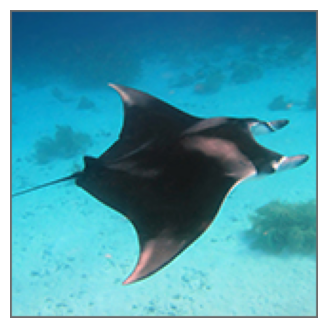

Prompt: Select the fish below.
Choices:
- piranha
- zebra
Answer concisely with the correct choice.
Ground Truth: piranha
Model Output:  piranha

--------------------------------------------------


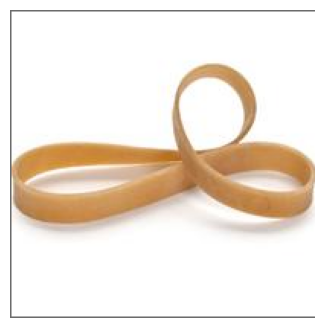

Prompt: Is rubber a mineral?
Choices:
- yes
- no
Answer concisely with the correct choice.
Ground Truth: no
Model Output:  no

--------------------------------------------------


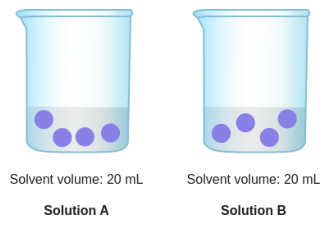

Prompt: Which solution has a higher concentration of purple particles?
Choices:
- Solution B
- neither; their concentrations are the same
- Solution A
Answer concisely with the correct choice.
Ground Truth: neither; their concentrations are the same
Model Output:  Solution B

--------------------------------------------------


In [8]:
for sample_data in prepared_samples:
    # Safely move inputs to the same device as the model
    inputs = sample_data["inputs"].to(model.device)



    # Generate output IDs
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            pad_token_id=processor.tokenizer.eos_token_id
        )

    # Decode ONLY the newly generated tokens to text
    new_tokens = generated_ids[:, inputs["input_ids"].shape[1]:]
    output_text = processor.batch_decode(new_tokens, skip_special_tokens=True)[0]

    # Display results
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_data["image"])
    plt.axis("off")
    plt.show()
    print(f"Prompt: {sample_data['prompt']}\nGround Truth: {sample_data['ground_truth']}\nModel Output: {output_text}\n" + "-"*50)




## 3. Playing with Tokens: Analyzing the Input Sequence

When a VLM encounters an image, it converts the picture into a series of 'visual tokens' and integrates them with the text tokens, forming a single prompt for the LLM.

### Task 1.3: Structural Token Analysis

Complete the cell below to inspect the input_ids tensor generated from the last processed sample. Your task is to use this tensor to calculate the exact number of visual tokens and text tokens present in the sequence.



In [9]:
input_ids = inputs.input_ids

# Find the token ID for image pads
image_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")

# Count visual tokens and text tokens
num_visual_tokens = torch.sum(input_ids == image_token_id).item()
num_text_tokens = input_ids.shape[1] - num_visual_tokens

print(f"Visual Tokens: {num_visual_tokens} | Text Tokens: {num_text_tokens}")

Visual Tokens: 96 | Text Tokens: 54


**Question 1.3a (Empirical Analysis):** Review the printed token counts from the code execution above. Calculate the exact percentage of the total input sequence length ($N$) that is occupied by the visual tokens versus the textual tokens. What does this distribution tell you about how a VLM allocates its processing capacity compared to a text-only LLM?

**Student's Answer:**


<div dir="rtl">

با توجه به تعداد توکن‌های ارائه شده، تحلیل تجربی و پاسخ به سوال به شرح زیر است:

### ۱. محاسبه درصد توکن‌ها

* **تعداد کل توکن‌ها ($N$):** $96 + 54 = 150$
* **درصد توکن‌های تصویری (Visual):** $$\left( \frac{96}{150} \right) \times 100 = 64\%$$
* **درصد توکن‌های متنی (Textual):** $$\left( \frac{54}{150} \right) \times 100 = 36\%$$

---

### ۲. تحلیل و نتیجه‌گیری (Insights)

این توزیع نشان می‌دهد که 64 درصد از کل طول توالی ورودی توسط توکن‌های تصویری اشغال شده است و تنها 36 درصد آن به توکن‌های متنی اختصاص دارد.

 **نحوه تخصیص ظرفیت پردازشی:** حتی برای یک پرامپت متنی کوتاه، تصویر نزدیک به دو-سوم از Context Window مدل را به خود اختصاص داده است. این امر نشان می‌دهد که یک VLM بخش عظیمی از پهنای باند محاسباتی و حافظه خود را صرفاً برای بازنمایی و پردازش جزئیات مکانی و بصری تصویر صرف می‌کند.

 **مقایسه با LLMهای فقط متنی:** در یک مدل فقط متنی، 100 درصد ظرفیت توالی برای بافت زبانی (متن) محفوظ است که اجازه مکالمات طولانی‌تر یا پردازش اسناد حجیم را می‌دهد. در مقابل، یک VLM Context Budget خود را خیلی سریع با تصاویر مصرف می‌کند؛ به همین دلیل داشتن Context window بزرگتر  برای مدل‌های چندرسانه‌ای بسیار حیاتی‌تر است تا بتوانند هم‌زمان عمق تحلیل متنی و استدلال خود را حفظ کنند.

</div>

**Question 1.3b (Mathematical Complexity Analysis):** Consider the standard computational cost formula per forward pass for a single Transformer processing an input sequence:

$$\text{Total FLOPs} = T \times (4nd^2 + 2n^2d + 2ndm)$$

Where:

- $n$ is the sequence length (total number of tokens).
- $d$ is the model's hidden embedding dimension size.
- $m$ is the intermediate dimension size of the MLP layer.
- $T$ is the number of transformer blocks/layers.

Based on this formula and the token counts you extracted in Task 1.3, identify which specific term inside the parentheses poses the greatest computational threat when shifting from a text-only LLM to a Vision-Language Model. Explain why processing visual data scales the computational overhead so aggressively.

**Student's Answer:**


<div dir="rtl">

عبارتی که در داخل پرانتز بزرگ‌ترین تهدید محاسباتی را ایجاد می‌کند، عبارت **$2n^2d$** (هزینه محاسباتی مکانیزم Self-Attention) است.

#### **چرا این عبارت بزرگ‌ترین تهدید است؟**
* **رشد مربعی ($O(n^2)$):** در فرمول داده‌شده، عبارات $4nd^2$ و $2ndm$ نسبت به طول توالی ($n$) به صورت خطی رشد می‌کنند. اما عبارت مربوط به Self-Attention ($2n^2d$) دارای رشد **مربعی** ($n^2$) است.
* **تأثیر توکن‌های تصویری:** همان‌طور که در بخش 1.3a مشاهده شد، داده‌های تصویری حتی برای یک تصویر واحد، تعداد بسیار زیادی توکن ($n$) ایجاد می‌کنند (که در تحلیل تجربی ما ۶۴ درصد از کل توالی را اشغال کرد). هنگام انتقال از یک LLM فقط متنی به یک مدل VLM، مقدار $n$ به شدت بزرگ می‌شود.

#### **چرا پردازش داده‌های تصویری بار محاسباتی را تا این حد تهاجمی بالا می‌برد؟**
مکانیزم Self-Attention نیازمند این است که تک‌تک توکن‌ها به تمام توکن‌های دیگر در کل توالی توجه کنند و در آن‌ها ضرب شوند. وقتی پیکسل‌های متراکم و تصاویر با رزولوشن بالا به صدها یا هزاران توکن تصویری تبدیل می‌شوند، وابستگی فرمول به $n^2$ باعث می‌شود که حجم محاسبات مورد نیاز و فضای حافظه به صورت انفجاری و مربعی افزایش یابد. این مسئله پردازش تصاویر را در مقایسه با مدل‌های متنی (که طول توالی در آن‌ها بسیار تدریجی‌تر رشد می‌کند) به شدت سنگین و پرهزینه می‌سازد.

</div>

# S2: Dynamic Resolution and Efficient Inference

**Objective:** In this section, you will explore how Qwen processes images, manage memory and accelerate inference speed by controlling image resolution.

## 1. Dynamic Resolution Mechanism

Older Vision-Language Models required all input images to be resized or cropped to a fixed resolution before processing. Qwen utilizes a more advanced approach called Dynamic Resolution.

### Task 2.1: Dynamic Resolution

Review the official documentation or technical reports for the Qwen-VL architecture (e.g., the [Qwen2-VL Paper](https://arxiv.org/abs/2409.12191) or [Qwen2.5-VL Blog Post](https://qwen.ai/blog?id=qwen2.5-vl)). Write a brief paragraph explaining how Qwen handles images of varying sizes and aspect ratios. How does it preserve the original image structure without forcing a rigid resize?

**Student's Answer:**



<div dir="rtl">

مدل Qwen با معرفی مکانیزم Native Dynamic Resolution در شبکه پایه ترنسفورمر بینایی (ViT) خود، محدودیت‌های مدل‌های سنتی با رزولوشن ثابت را برطرف کرده است. این مدل به جای اجبار به تغییر سایز یا برش زدن تصاویر به شکل مربع‌های از پیش تعیین‌شده — که اغلب باعث دفرمه شدن نسبت ابعاد تصویر یا از دست رفتن جزئیات حیاتی می‌شود — تصاویر ورودی را در طول مراحل پیش‌آموزش و استنتاج با همان رزولوشن و ابعاد واقعی خودشان پردازش می‌کند.

در این ساختار، تصویر به صورت پویا با استفاده از استراتژی گروه‌بندی پچ‌های متغیر، به تعداد توکن‌های بصری متفاوتی تبدیل می‌شود. جهت حفظ ساختار هندسی و روابط مکانی اصلی تصویر بدون ایجاد دگرگونی در پیکسل‌ها، مدل Qwen از امبدینگ موقعیتی چرخشی چندرسانه‌ای استفاده می‌کند. این معماری به طور بومی کدگذاری‌های موقعیتی را به مؤلفه‌های مجزا تجزیه می‌کند تا ابعاد زمانی و ابعاد مکانی دو بعدی ($H$ و $W$) را به طور مستقل ثبت کند. در نتیجه، مدل می‌تواند تصاویر عریض، عمودی یا اسناد با کیفیت بالا را در نسبت‌های ابعاد بسیار متنوع به راحتی درک کرده و یکپارچگی ساختاری تصویر را کاملاً حفظ کند.

</div>

## 2. Baseline Inference (High Resolution)

To measure the impact of resolution on speed and accuracy, we first need to establish a baseline. We will evaluate the model on 100 samples using its default, unrestricted resolution settings.

### Task 2.2a: Prepare the Evaluation Subset

Complete and run the cell below to randomly select 100 image-based questions from the ScienceQA dataset. Crucially, we extract these samples from the test split to prevent any data leakage during the training phase later.


In [10]:
test_image_data = load_dataset("derek-thomas/ScienceQA")["test"].filter(lambda x: x['image'] is not None)

# Randomly sample 100 items from test_image_data (seed=42)
random.seed(42)
random_indices = random.sample(range(len(test_image_data)), 100)
eval_samples = test_image_data.select(random_indices)

print(eval_samples)

Filter:   0%|          | 0/4241 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
    num_rows: 100
})


### Task 2.2b: Run Baseline Evaluation

Complete the code below to run the inference loop on the 100 selected samples. We will use the standard processor from the previous section. The code includes a timer to track exactly how long the entire batch takes.


In [ ]:
model.eval()
correct_predictions = 0
start_time = time.time()
for sample in eval_samples:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # Build messages and apply chat template (disable thinking mode)
    messages = [{"role": "user", "content": [
        {"type": "image", "image": sample["image"]},
        {"type": "text", "text": full_prompt},
    ]}]
    text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True,enable_thinking=False)

    # Process vision info and get model inputs
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text_prompt], images=image_inputs, return_tensors="pt").to(model.device)

    # Generate outputs and decode the text
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=64,
            pad_token_id=processor.tokenizer.eos_token_id
        )
        input_len = inputs.input_ids.shape[1]
        output_text = processor.batch_decode(generated_ids[:, input_len:], skip_special_tokens=True)[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions += 1

total_time = time.time() - start_time
accuracy = (correct_predictions / len(eval_samples)) * 100
print(f"Baseline (High-Res) -> Time: {total_time:.2f}s | Accuracy: {accuracy:.2f}%")


Baseline (High-Res) -> Time: 572.10s | Accuracy: 65.00%


## 3. Low-Resolution Inference

Now, we will restrict the image resolution before passing it to the model. By setting a specific `max_pixels` limit, we force the processor to generate fewer visual patches.

### Task 2.3: Re-initialize Processor and Re-evaluate

Run the cell below. It creates a new processor with a strict pixel limit and evaluates the exact same 100 samples. Observe how the time and accuracy metrics change.

(Note: The minimum acceptable resolution for `max_pixels` in this exercise is 32 * 28 * 28.)


In [ ]:
# Initialize low-resolution processor
processor_low_res = AutoProcessor.from_pretrained(
    model_id,
    max_pixels = 32 * 28 * 28
)

model.eval()
correct_predictions = 0
start_time = time.time()

for sample in eval_samples:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # Build messages and apply chat template (disable thinking mode)
    messages = [{"role": "user", "content": [
        {"type": "image", "image": sample["image"]},
        {"type": "text", "text": full_prompt},
    ]}]

    text_prompt = processor_low_res.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    # Process vision info and get model inputs
    image_inputs, _ = process_vision_info(messages)

    inputs = processor_low_res(
        text=[text_prompt],
        images=image_inputs,
        return_tensors="pt"
    ).to(model.device)

    # Generate outputs and decode the text
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            pad_token_id=processor.tokenizer.eos_token_id
        )
        input_len = inputs.input_ids.shape[1]
        output_text = processor_low_res.batch_decode(
            generated_ids[:, input_len:],
            skip_special_tokens=True
        )[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions += 1

total_time = time.time() - start_time
accuracy = (correct_predictions / len(eval_samples)) * 100

print(f"Low-Res -> Time: {total_time:.2f}s | Accuracy: {accuracy:.2f}%")


Low-Res -> Time: 157.27s | Accuracy: 51.00%


## 4. Mathematical Complexity Analysis

You should have noticed a difference in execution time and perhaps accuracy between the baseline and the low-resolution evaluation. Let's analyze exactly why this happens.

### Task 2.4: Comparative and Root Cause Analysis

First, create a simple chart or table (you can use Python or write it directly in your text answer) comparing the execution time and accuracy between the Baseline (High Resolution) and the Low-Resolution inference.

Based on your comparison:

1. **Accuracy Change:** How did the accuracy change? If there was a drop in accuracy, was it severe (causing the model to completely lose its ability to answer correctly), or was it minimal? What conclusion can you draw from this regarding the model's visual reasoning capabilities at lower resolutions?

2. **Time Change:** Recalling the Total FLOPs formula from the previous section, explain the exact reason for the change in execution time. Why does reducing the image resolution lead to an increase in inference speed?

**Student's Answer:**


<div dir="rtl">

#### **جدول مقایسه عملکرد**

| شاخص | حالت پایه (رزولوشن بالا) | رزولوشن پایین | میزان تغییرات |
| :--- | :---: | :---: | :---: |
| **زمان استنتاج (ثانیه)** | 572.10s | 157.27s | حدود 72.5٪ سریع‌تر |
| **دقت (Accuracy)** | 65.00% | 51.00% | 14% کاهش |

---

#### **۱. تحلیل تغییرات دقت (Accuracy Change)**
مدل با یک کاهش 14 درصدی در دقت مواجه شده است. اگرچه این افت عملکرد کاملاً ملموس است، اما خیلی شدید و فاجعه‌بار نیست؛ چرا که مدل توانایی استدلال بصری خود را به طور کامل از دست نداده و همچنان بسیار بالاتر از حد حدس تصادفی عمل می‌کند.

از این تغییر می‌توان نتیجه گرفت که مدل مجهز به یک درک معنایی کلی و پایدار است. کاهش رزولوشن باعث می‌شود مدل جزئیات ظریف و فرکانس‌بالای تصویر (مانند متن‌های ریز یا ویژگی‌های بسیار کوچک) را از دست بدهد، اما استدلال فضایی اصلی و درک بافتار کلی صحنه همچنان حفظ می‌شود.

#### **۲. تحلیل تغییرات زمان و ریشه‌یابی علت آن (Time Change)**
سرعت استنتاج مدل به طرز چشمگیری بهبود یافته و زمان اجرا تا **72.5٪** کاهش یافته است (صرفه‌جویی در بیش از 414 ثانیه).


علت دقیق این جهش سرعت فوق‌العاده، در عبارت مربوط به Self-Attention یعنی **$(2n^2d)$** نهفته است:
* کاهش رزولوشن تصویر به طور مستقیم تعداد پچ‌های بصری را کم می‌کند که این امر منجر به کاهش شدید طول توالی کل ($n$) می‌شود.
* از آنجا که پیچیدگی محاسباتی مکانیزم Self-Attention به صورت **مربعی ($n^2$)** با طول توالی رابطه دارد، یک کاهش خطی در تعداد توکن‌ها، باعث کاهش نمایی (درجه دو) در کل عملیات‌های ممیز شناور و بار حافظه می‌شود.
* در نتیجه، کوچک کردن $n$ گلوگاه محاسباتی عظیم داخل بلوک‌های ترنسفورمر را از بین برده و منجر به این شتاب‌دهی عمیق در زمان استنتاج شده است.

</div>


---

**Important Notice for the Next Section**

In the upcoming section (Section 3), we plan to fine-tune the model on the ScienceQA dataset. Because training a model requires significantly more memory (RAM/VRAM) to store gradients compared to simple inference, you are highly likely to encounter Out of Memory (OOM) errors if you attempt to train on high-resolution images.

To bypass this hardware limitation, we will be forced to decrease the image resolution during the fine-tuning process (e.g., using the `max_pixels = 32 * 28 * 28` setting).

**Crucial Note:** For your final evaluation at the end of Section 3 to be scientifically valid, the restricted resolution you utilize here in Task 2.3 must be exactly the same as the resolution you will use during the fine-tuning phase. This ensures a strictly accurate comparison between the pre-trained and fine-tuned models.

# S3: Supervised Fine-Tuning (with LoRA)

**Objective:** In this section, you will implement Low-Rank Adaptation (LoRA) to fine-tune the Qwen3.5 0.8B model. You will format multimodal data for training, configure memory-efficient training parameters, and evaluate the final fine-tuned model against your previous baseline.

## 1. Preparing the Training Data

To train the model, we need to convert the raw dataset into the exact chat structure the model expects.

### Task 3.1: Data Formatting and Structure

Complete the code below to extract a 1,000-sample subset from the ScienceQA dataset for training. Crucially, ensure this subset strictly contains image-based questions, as our goal is to train the visual reasoning capabilities of the model.

In [11]:
train_image_data = load_dataset("derek-thomas/ScienceQA")["train"].filter(lambda x: x['image'] is not None)
random.seed(42)
train_subset = random.sample(list(train_image_data), 1000)

formatted_train_data = []

for sample in train_subset:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # Build messages list ('user' gets image+prompt, 'assistant' gets ground_truth)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": ground_truth}
            ]
        }
    ]

    formatted_train_data.append({"messages": messages})



Filter:   0%|          | 0/12726 [00:00<?, ? examples/s]

## 2. LoRA Configuration for VLMs

Fine-tuning an entire Vision-Language Model on standard hardware is extremely difficult due to massive memory requirements. We will use the `peft` library to apply Low-Rank Adaptation (LoRA), which freezes the base model and only trains a tiny set of injected weight matrices.

### Task 3.2: Configure PEFT

Review the Qwen3.5 architecture and standard LoRA practices. You need to identify which specific layers within the Large Language Model component should be targeted for adaptation. Do not target the Vision component layers.


In [12]:
!pip install torchao==0.16.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [13]:
from peft import LoraConfig, get_peft_model

# Configure LoRA (target ONLY LLM layers)
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

# Apply PEFT model
model_lora = get_peft_model(model, peft_config)

# Print trainable parameters
model_lora.print_trainable_parameters()


trainable params: 6,389,760 || all params: 859,375,680 || trainable%: 0.7435


## 3. The Training Loop

We will use Hugging Face's `Trainer` mapped for VLMs to handle the training loop. Because training memory footprint is heavily dependent on sequence length, we must strictly manage hardware constraints. To make the process clear, we will break the training setup into three smaller steps.

### Task 3.3a: Setup the Processor and Data Collator

Complete and run the cell below to load our restricted-resolution processor and define a custom `DataCollator` that processes multimodal inputs dynamically during training.


In [14]:
# Load low-res processor for memory efficiency during training
processor_train = AutoProcessor.from_pretrained(model_id, max_pixels=32 * 28 * 28)

def multimodal_data_collator(features):
    texts = []
    images = []
    prompt_lengths = []

    for feature in features:
        messages = feature["messages"]

        full_text = processor_train.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False
        )
        texts.append(full_text)

        prompt_text = processor_train.apply_chat_template(
            messages[:-1],
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
        )

        # Tokenize prompt to compute its length
        prompt_inputs = processor_train(text=[prompt_text], return_tensors="pt")
        prompt_lengths.append(prompt_inputs["input_ids"].shape[1])

        image_inputs, _ = process_vision_info(messages)
        images.extend(image_inputs)

    batch = processor_train(
        text=texts,
        images=images if any(img is not None for img in images) else None,
        return_tensors="pt",
        padding=True
    )

    batch["labels"] = batch["input_ids"].clone()

    # Mask padding tokens so they do not contribute to loss
    batch["labels"][batch["attention_mask"] == 0] = -100

    # Mask prompt tokens (user question + choices)
    for i, prompt_len in enumerate(prompt_lengths):
        batch["labels"][i, :prompt_len] = -100

    return batch


### Task 3.3b: Configure Training Arguments

The acceptable training configurations are specified within the code comments below. If your hardware encounters memory limitations (such as Out of Memory errors) or exceptionally slow training times, you should lower these parameters accordingly to successfully complete the fine-tuning process. Run the cell below to configure them.




In [15]:
from transformers import TrainingArguments

# Configure TrainingArguments (handle batch_size and gradient_accumulation carefully for OOM)
training_args = TrainingArguments(
    output_dir="./qwen_lora_sft",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=2,
    warmup_steps=30,
    logging_steps=10,
    save_steps=200,
    save_total_limit=2,
    fp16=True,
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=0,
    report_to="none",
    gradient_checkpointing=True,
    optim="adamw_torch",
    max_grad_norm=1.0
)


### Task 3.3c: Initialize Trainer and Execute

Run the cell below to piece everything together into the `Trainer` and start the Fine-Tuning process.


In [16]:
# Initialize Trainer with model, args, dataset, and collator
trainer = Trainer(
    model=model_lora,
    args=training_args,
    train_dataset=formatted_train_data,
    data_collator=multimodal_data_collator
)

# Start training
trainer.train()

# Save the fine-tuned model
trainer.save_model("./qwen_lora_sft")


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
10,2.127012
20,0.924485
30,0.335965
40,0.411048
50,0.266859
60,0.086837
70,0.107081
80,0.132826
90,0.078416
100,0.081604


## 4. Secondary Evaluation

With the model fine-tuned, it is time to measure the impact of our training. We will evaluate the fine-tuned model using the exact same evaluation dataset and settings from Section 2.

### Task 3.4: Evaluate the Fine-Tuned Model

Run the exact same 100 evaluation samples from Task 2.2 using the newly fine-tuned model and the restricted low-resolution processor.



In [17]:
from peft import PeftModel

# Initialize low-resolution processor
base_model = AutoModelForMultimodalLM.from_pretrained(
    model_id,
    dtype="bfloat16",
    device_map="auto"
)
# Evaluate the fine-tuned model on eval_samples using processor_train
lora_model = PeftModel.from_pretrained(
    base_model,
    "./qwen_lora_sft"
)

fine_tuned_model = lora_model.merge_and_unload()


fine_tuned_model.eval()

processor_eval = processor_train
correct_predictions = 0
start_time = time.time()

for sample in eval_samples:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # Build messages and apply chat template (disable thinking mode)
    messages = [
        {"role": "user", "content": [
        {"type": "image", "image": sample["image"]},
        {"type": "text", "text": full_prompt},
    ]}]

    text_prompt = processor_eval.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    # Process vision info and get model inputs
    image_inputs, _ = process_vision_info(messages)

    inputs = processor_eval(
        text=[text_prompt],
        images=image_inputs,
        return_tensors="pt"
    ).to(fine_tuned_model.device)

    # Generate outputs and decode the text
    with torch.no_grad():
        generated_ids = fine_tuned_model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            pad_token_id=processor.tokenizer.eos_token_id
        )
        input_len = inputs.input_ids.shape[1]
        output_text = processor_eval.batch_decode(
            generated_ids[:, input_len:],
            skip_special_tokens=True
        )[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions += 1

total_time = time.time() - start_time
accuracy = (correct_predictions / len(eval_samples)) * 100

print(f"Low-Res -> Time: {total_time:.2f}s | Accuracy: {accuracy:.2f}%")



Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Low-Res -> Time: 114.00s | Accuracy: 80.00%


# S4: Critical Analysis
---

### Task 4.1: The Tripartite Trade-off

Throughout this exercise, you have gathered metrics for three distinct states of the model. Fill in the comparison table below with the data you collected:

| Model State | Resolution (max_pixels) | Total Inference Time (s) | Accuracy (%) |
| --- | --- | --- | --- |
| **A) Baseline (High Res)** | Default (Unrestricted) | 572.10s | 65%  |
| **B) Baseline (Low Res)** | 32 * 28 * 28 | 157.27s | 51% |
| **C) Fine-Tuned (Low Res)** | 32 * 28 * 28 | 114s | 80% |

Based on the data in your table, analyze the "Speed-Accuracy Trade-off." Did the computational time and effort spent fine-tuning the model in Section 3 justify the final inference speed and accuracy achieved in state (C)?

**Student's Answer:**


<div dir="rtl">

<div align="center">

| وضعیت مدل (Model State) | رزولوشن (max_pixels) | کل زمان استنتاج (ثانیه) | دقت (Accuracy %) |
| :--- | :---: | :---: | :---: |
| **حالت پایه (رزولوشن بالا)** | پیش‌فرض (بدون محدودیت) | 572.10s | 65.00% |
| **حالت پایه (رزولوشن پایین)** | 32 * 28 * 28 | 157.27s | 51.00% |
| **مدل فاین‌تیون شده (رزولوشن پایین)** | 32 * 28 * 28 | 114.00s | 80.00% |
</div>

---

#### **تحلیل موازنه سرعت-دقت و توجیه اقتصادی پروژه (Speed-Accuracy Trade-off)**

 زمان محاسباتی و هزینه‌ای که صرف فاین‌تیون کردن (Fine-tuning) مدل در بخش 3 شد، به طور کامل دستاوردها و نتایج نهایی به دست آمده را توجیه می‌کند. دلایل این تحلیل به شرح زیر است:

  در حالت عادی، موازنه سرعت و دقت توسعه‌دهندگان را مجبور می‌کند یکی از این دو فاکتور را فدای دیگری کنند (همان‌طور که در انتقال از حالت پایه به حالت با رزولوشن پایین دیدیم؛ سرعت 72.5% بالاتر رفت اما دقت 14% افت کرد). با این حال، مدل فاین‌تیون شده با لورا این مشکل را حل کرده است: هم 80% سریع‌تر از حالت پایه و اولیه است (114 ثانیه در برابر 572 ثانیه) و همزمان دقت را به رقم فوق‌العاده 80% رسانده است .

 کم کردن رزولوشن تصویر به طور ذاتی باعث حذف و از دست رفتن داده‌های بصری خام می‌شود. فرآیند فاین‌تیونینگ با موفقیت به مدل یاد داده است که چطور با استفاده از توکن‌های تصویری کمتر و فشرده‌تر، تسک‌های تخصصی دامین مربوطه را به بهترین شکل جلو ببرد. این کار وزن‌های مدل را به گونه‌ای تنظیم کرده که با توزیع پچ‌های رزولوشن پایین سازگار شوند و شکاف معنایی ناشی از کاهش کیفیت تصویر پر شود.

 اگرچه فاین‌تیون کردن مدل نیازمند صرف یک هزینه اولیه برای سخت‌افزار و زمان آموزش است، اما دستاورد آن در فاز پروداکشن و استنتاج انبوه بسیار عظیم است. جالب اینجاست که وضعیت نهایی حتی نسبت به وضعیت رزولوشن پایین نیز زمان اجرای بهتری ثبت کرده است (114 ثانیه در برابر 157 ثانیه)، که احتمالاً به دلیل همگرایی سریع‌تر مدل در تولید توکن‌های خروجی و پاسخ‌های قطعی‌تر و کوتاه‌تر است. برای هرگونه استقرار واقعی در صنعت، این کاهش چشمگیر در تاخیر پاسخ‌دهی (Latency) و بار محاسباتی، همراه با دقت بالاتر، سرمایه‌گذاری روی فاز آموزش را کاملاً تایید و توجیه می‌کند.

</div>

---

### Task 4.2: Understanding Visual Redundancy
Look at your table from Task 4.1 and compare the rate of change in resolution versus the rate of change in accuracy when moving from State (A) to State (B).

In machine learning, this specific behavior is related to the concept of data "redundancy." Based on your results, explain what visual redundancy means. Why can a model still logically process an image after losing a massive percentage of its visual patches, whereas dropping the exact same percentage of words from a text prompt would completely destroy its meaning?

**Student's Answer:**



<div dir="rtl">

#### **۱. تعریف Visual Redundancy بر اساس نتایج:**
با مقایسه وضعیت (A) و وضعیت (B)، مشاهده می‌شود که با وجود کاهش شدید رزولوشن، دقت مدل با نرخ بسیار کندتر و به صورت غیرخطی افت می‌کند. این شکاف دقیقاً نشان‌دهنده مفهوم  Visual Redundancy است؛ پدیده‌ای که در آن داده‌های تصویری با ابعاد بالا، حاوی مقادیر عظیمی از اطلاعات هم‌پوشان، تکراری یا به شدت قابل پیش‌بینی هستند. به عبارت دیگر، پیکسل‌ها یا پچ‌های مجاور در یک تصویر، اطلاعات مشترک زیادی با یکدیگر دارند، به این معنی که معنای اصلی و نهفته در تصویر را می‌توان با مجموعه بسیار کوچک‌تری از داده‌ها نیز بازنمایی کرد.

---

#### **۲. مقایسه حذف پچ‌های تصویری در برابر متنی:**
تفاوت بنیادی در نحوه ساختاریافتگی تراکم اطلاعات و سینتکس در بینایی ماشین در مقایسه با زبان طبیعی نهفته است:

 **همبستگی فضایی در مقابل وابستگی متوالی:** تصاویر دارای همبستگی فضایی قوی هستند. اگر یک پچ از یک آسمان آبی یا یک دیوار آجری حذف شود، مدل به راحتی می‌تواند داده‌های از دست رفته را بر اساس پچ‌های اطراف حدس بزند (مشابه مکانیزم عملکرد Masked Autoencoders). اما متن به شدت متوالی، زنجیره‌ای و گسسته است. هر کلمه یا توکن بار معنایی و نحوی منحصربه‌فرد و سنگینی را حمل می‌کند.

 **تراکم اطلاعات:** داده‌های تصویری به ازای هر توکن، کم‌تراکم هستند؛ یک پچ تصویری تکی معمولاً فقط شامل چند خط مبهم یا یک رنگ یکنواخت است. در مقابل، متن به ازای هر توکن، متراکم است. حذف حتی یک کلمه کلیدی مانند *"نه" (not)*، *"هرگز" (never)* یا یک اسم اصلی، جهت منطقی جمله را کاملاً معکوس کرده یا ساختار گرامری آن را به کل نابود می‌کند.
 
 **تاب‌آوری در برابر انسداد:** مدل‌های بینایی عمیق (مانند Vision Transformers یا ViTs) یاد می‌گیرند که ویژگی‌های کلان (Macro-features) مثل لبه‌ها، خطوط محیطی و بافت کلی را درک کنند و نیازی به تک‌تک پیکسل‌ها برای تشخیص یک شیء ندارند. اما در متن، مدل‌های زبانی فاقد این نوع درونیابی فضایی هستند؛ یک کلمه حذف شده یک خلأ منطقی بزرگ ایجاد می‌کند که نمی‌توان آن را صرفاً با میانگین‌گیری از کلمات مجاور پر کرد.

</div>

### Task 4.3: Exploring the Frontiers of Efficiency

In this exercise, we relied heavily on "Dynamic Resolution Reduction" to fit the VLM inference and training onto constrained hardware. However, this is just one approach in the broader field of efficient AI.

Research the current literature on Large Vision-Language Models. Identify and name at least **two other techniques** used to accelerate inference and reduce memory (VRAM) consumption. Provide a concise, one-sentence explanation of the core mechanism for each technique.

**Student's Answer:**


<div dir="rtl">

**هرس پویای توکن (Dynamic Token Sparsity / Token Pruning)**  
این روش با شناسایی و حذف توکن‌های بصری کم‌اهمیت بر اساس Attention Scores در هر لایه، تعداد توکن‌های پردازشی و حجم حافظه نهان KV را کاهش می‌دهد.  
 `ZipVL: Accelerating Vision-Language Models through Dynamic Token Sparsity`  

---

**هرس کانال کلید هم‌تراز با چرخش (Rotation-Aligned Key Channel Pruning)**  
این روش با اعمال چرخش مبتنی بر PCA، اهمیت کانال‌های وابسته به توکن را در یک زیرفضای مشترک هم‌تراز کرده و هرس ساختاری کانال‌های کلید را با دقت بالا امکان‌پذیر می‌سازد.  
 `Rotation-Aligned Key Channel Pruning for Efficient Vision-Language Model Inference`

</div>

### Task 4.4: Task-Specific Resolution Sensitivity
In our experiment, you saw how reducing the resolution affected the accuracy on the ScienceQA dataset. Do you think this result would be the same for all types of visual tasks?

Compare the ScienceQA dataset to a dataset focused on reading dense charts, complex graphs, or document text (e.g., ChartQA or DocVQA). How would extreme resolution reduction affect the accuracy in those cases, and why?

*(Note: You do not need to write code or run any tests for this question. Just provide your analytical opinion).*

**Student's Answer:**



<div dir="rtl">

#### **حساسیت عملکرد به وضوح تصویر در تسک‌های مختلف (Task-Specific Sensitivity):**
خیر، معتقدم این نتایج برای همه تسک‌های بینایی یکسان نخواهد بود. میزان حساسیت مدل به کاهش رزولوشن، کاملاً وابسته به **«تراکم اطلاعات معنایی در واحد سطح»** در آن تسک خاص است. علمکرد مدل روی مجموعه‌داده‌ای مانند ScienceQA (که بیشتر شامل تصاویر علمی کلی، نمودارهای ساده یا اشکال مفهومی است) با کاهش وضوح دچار افت شدید نمی‌شود، زیرا ویژگی‌های کلان تصویری مانند رنگ‌ها، فرم‌های هندسی کلی و ساختارهای بزرگ حتی با پچ‌های بزرگ‌تر یا رزولوشن پایین‌تر نیز قابل شناسایی هستند.

---

#### **مقایسه با داده‌های متنی-تصویری (مانند ChartQA یا DocVQA):**
در مجموعه‌داده‌هایی مانند **ChartQA** یا **DocVQA** که هدف اصلی آن‌ها خواندن نمودارهای متراکم، گراف‌های پیچیده یا متن اسناد است، کاهش شدید رزولوشن فاجعه‌بار خواهد بود و منجر به افت شدید و ناگهانی دقت مدل می‌شود. دلایل اصلی این پدیده عبارتند از:

**وابستگی شدید به ویژگی‌های ریزدانه:** در خواندن اسناد یا نمودارها، معنای کل تصویر به جزئیات فوق‌العاده کوچک نظیر خطوط باریک راهنما، اعداد روی محورها، برچسب‌های متنی ریز (Labels) و کاراکترهای متنی وابسته است. کاهش رزولوشن باعث محو شدن یا به اصطلاح "Aliasing" این بخش‌ها می‌شود.

**از بین رفتن ساختار کاراکترها:** هنگامی که رزولوشن کاهش می‌یابد، تعداد پیکسل‌های اختصاص‌یافته به هر کاراکتر متنی کمتر از حد آستانه تشخیص مدل می‌شود. در نتیجه، حروف و اعداد به لکه‌های پیکسلی مبهم تبدیل شده و ماژول بینایی مدل عملاً قادر به استخراج توکن‌های متنی صحیح برای ارسال به بخش زبانی نخواهد بود.

**عدم وجود Visual Redundancy:** برخلاف تصاویر طبیعی یا اشکال کلی، در یک سند متنی یا یک چارت پیچیده، تقریبا هیچ پیکسلی «اضافه» یا قابل حدس زدن نیست. حذف یا فشرده‌سازی پچ حاوی یک عدد روی نمودار، برخلاف حذف پچ آسمان، قابل جبران توسط پچ‌های همسایه نیست و کل زنجیره استدلال مدل را قطع می‌کند.

</div>